<h2>Importing Libraries</h2>

In [57]:

import pandas as pd
import numpy as np

np.random.seed(42)

n = 1000

df = pd.DataFrame({
    "age": np.random.randint(18, 60, n),
    "daily_active_time": np.random.randint(10, 300, n),
    "posts_last_week": np.random.randint(0, 20, n),
    "likes_last_week": np.random.randint(0, 200, n),
    "activity_type": np.random.choice(["tech", "sports", "music"], n),
    "past_participation_rate": np.random.rand(n),
    "friends_participating": np.random.randint(0, 10, n),
    "time_of_day": np.random.choice(["morning", "evening"], n),
    "day_of_week": np.random.choice(["weekday", "weekend"], n)
})

df["engaged"] = (
    (df["daily_active_time"] > 100) &
    (df["likes_last_week"] > 50) |
    (df["past_participation_rate"] > 0.5)
).astype(int)

df.head()

,age,daily_active_time,posts_last_week,likes_last_week,activity_type,past_participation_rate,friends_participating,time_of_day,day_of_week,engaged
0,56,166,0,72,music,0.782051,5,evening,weekday,1
1,46,56,3,71,music,0.240071,4,evening,weekend,0
2,32,182,13,115,music,0.144309,0,evening,weekday,1
3,25,139,0,172,tech,0.115701,2,morning,weekend,1
4,38,104,13,80,sports,0.027250,0,morning,weekday,1


<h2>DATA DISTRIBUTION (EDA)</h2>

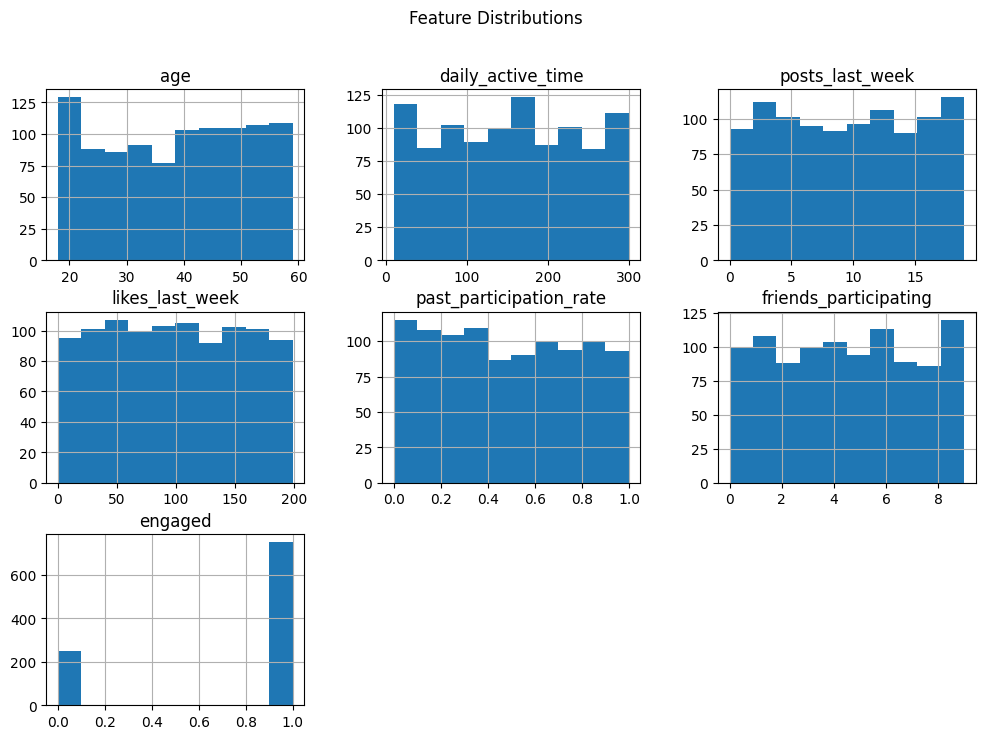

In [63]:
import matplotlib.pyplot as plt

#Distribution of numeric features
df.hist(figsize=(12, 8))
plt.suptitle("Feature Distributions")
plt.show()

<h2>Target Balance</h2>

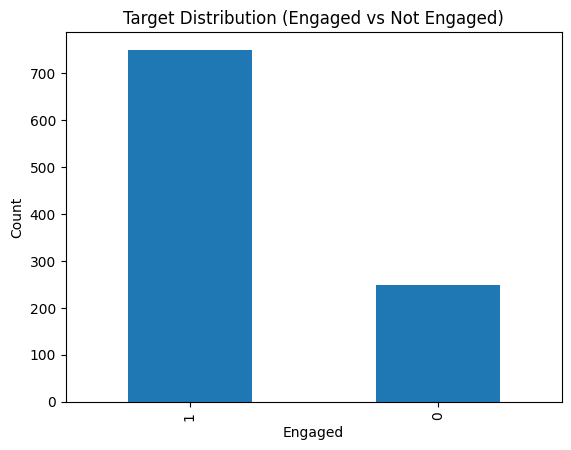

In [64]:
df["engaged"].value_counts().plot(kind="bar")
plt.title("Target Distribution (Engaged vs Not Engaged)")
plt.xlabel("Engaged")
plt.ylabel("Count")
plt.show()

<h2>Training & Testing Split</h2>

In [58]:
from sklearn.model_selection import train_test_split

X = df.drop("engaged", axis=1)
y = df["engaged"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(type(X_train))

<class 'pandas.core.frame.DataFrame'>


<h2>Feature Importance</h2>

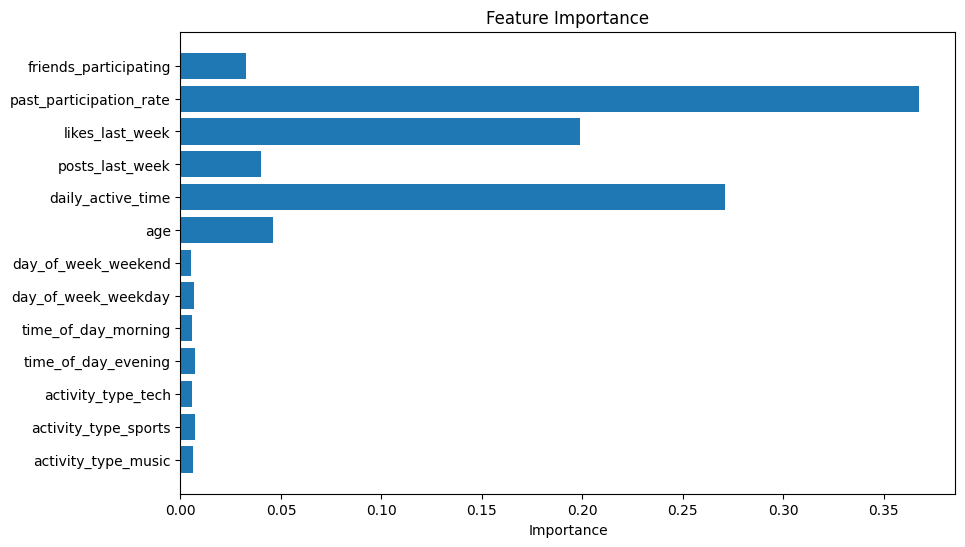

In [66]:
import numpy as np

# Get feature names after encoding
ohe = pipeline.named_steps["preprocessor"].named_transformers_["cat"]
encoded_features = ohe.get_feature_names_out(categorical_features)

all_features = list(encoded_features) + numerical_features

# Get importance
importances = pipeline.named_steps["model"].feature_importances_

# Plot
plt.figure(figsize=(10,6))
plt.barh(all_features, importances)
plt.title("Feature Importance")
plt.xlabel("Importance")
plt.show()

<h2>Preprocessing</h2>

In [59]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

categorical_features = ["activity_type", "time_of_day", "day_of_week"]

numerical_features = [
    "age",
    "daily_active_time",
    "posts_last_week",
    "likes_last_week",
    "past_participation_rate",
    "friends_participating"
]

preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features),
        ("num", "passthrough", numerical_features)
    ]
)

<h2>Model & Pipeline</h2>

In [60]:
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier

pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", RandomForestClassifier(random_state=42))
])

pipeline.fit(X_train, y_train)

,steps,"[('preprocessor', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('cat', ...), ('num', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


<h2>Evaluation</h2>

In [61]:
from sklearn.metrics import accuracy_score

y_pred = pipeline.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.995


<h2>Confusion Matrix</h2> 

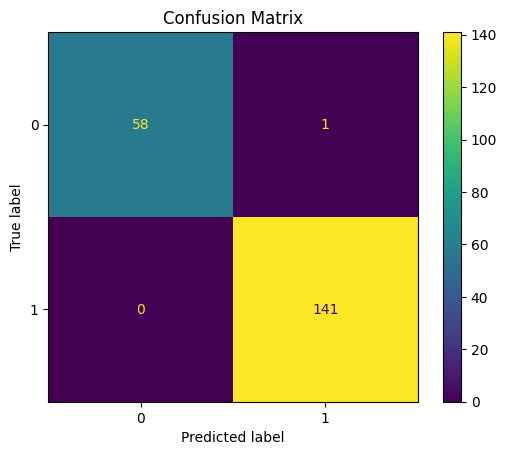

In [65]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.title("Confusion Matrix")
plt.show()

<h2>Prediction Probability Visualization</h2>

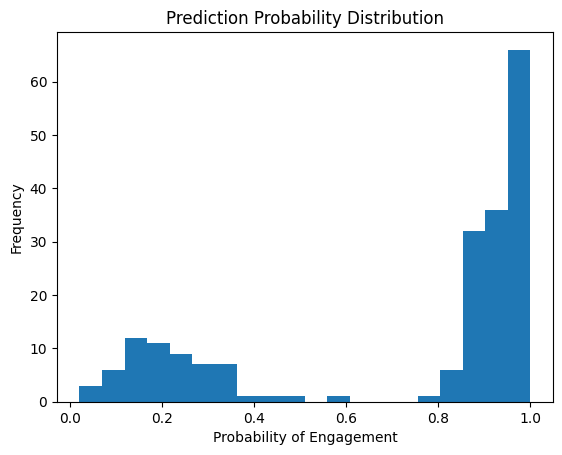

In [67]:
probs = pipeline.predict_proba(X_test)[:, 1]

plt.hist(probs, bins=20)
plt.title("Prediction Probability Distribution")
plt.xlabel("Probability of Engagement")
plt.ylabel("Frequency")
plt.show()

<h2>Model Saving</h2>

In [62]:
import pickle

with open("../models/model.pkl", "wb") as f:
    pickle.dump(pipeline, f)

print("Model saved successfully")

Model saved successfully
